# SAE Analysis for MusicGen Layer 22

This notebook analyzes the Sparse Autoencoder trained on MusicGen decoder layer 22 activations.


In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import json

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")


Using device: cuda


## 1. Load SAE Checkpoint and Data


In [50]:
# Paths
LAYER_IDX = 22
CHECKPOINT_PATH = Path("checkpoints") / f"sae_layer{LAYER_IDX:02d}.pt"
DATA_PATH = Path(f"/home/harinit9/orcd/pool/musicgen-activations-nokey/acts_by_layer/layer_{LAYER_IDX:02d}.npy")
METADATA_PATH = Path("/home/harinit9/orcd/pool/musicgen-data-nokey/dataset_metadata.json")

# Load checkpoint
ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
print(f"Loaded checkpoint with keys: {list(ckpt.keys())}")
print(f"d_in: {ckpt['d_in']}, d_hidden: {ckpt['d_hidden']}")
print(f"Expansion factor: {ckpt['d_hidden'] / ckpt['d_in']:.1f}x")


Loaded checkpoint with keys: ['sae_state_dict', 'mu', 'sigma', 'd_in', 'd_hidden', 'top_k', 'layer_idx']
d_in: 2048, d_hidden: 8192
Expansion factor: 4.0x


In [51]:
# Define SAE model (same as train_sae.py) - TopK version
class SAE(nn.Module):
    def __init__(self, d_in: int, d_hidden: int, top_k: int = 64):
        super().__init__()
        self.encoder = nn.Linear(d_in, d_hidden, bias=True)
        self.decoder = nn.Linear(d_hidden, d_in, bias=False)
        self.top_k = top_k

    def forward(self, x):
        z_pre = self.encoder(x)
        topk_vals, topk_idx = torch.topk(z_pre, self.top_k, dim=-1)
        z = torch.zeros_like(z_pre)
        z.scatter_(-1, topk_idx, torch.relu(topk_vals))
        x_hat = self.decoder(z)
        return x_hat, z

# Load model
top_k = ckpt.get('top_k', 64)  # Default for backwards compatibility
sae = SAE(ckpt['d_in'], ckpt['d_hidden'], top_k=top_k).to(DEVICE)
sae.load_state_dict(ckpt['sae_state_dict'])
sae.eval()

mu = ckpt['mu'].to(DEVICE)
sigma = ckpt['sigma'].to(DEVICE)
print(f"TopK: {top_k} features per sample")

print(f"SAE loaded successfully!")


TopK: 64 features per sample
SAE loaded successfully!


In [52]:
# Load activations and metadata
acts = np.load(DATA_PATH, mmap_mode='r')  # [N_CLIPS, T, D]
print(f"Activations shape: {acts.shape}")

with open(METADATA_PATH) as f:
    metadata = json.load(f)
print(f"Number of clips in metadata: {len(metadata)}")


Activations shape: (1000, 256, 2048)
Number of clips in metadata: 1000


In [55]:
# Prepare data for analysis (time-averaged)
X = torch.from_numpy(acts.mean(axis=1).astype(np.float32)).to(DEVICE)  # [N, D]
Xn = (X - mu) / sigma  # normalized
print(f"Normalized activations shape: {Xn.shape}")


Normalized activations shape: torch.Size([344, 2048])


In [58]:
# After filtering to good clips only, recompute normalization
X = torch.from_numpy(acts.mean(axis=1).astype(np.float32)).to(DEVICE)  # [N, D]

# Use checkpoint's mu/sigma OR recompute (try both)
# Option 1: Use checkpoint (if trained on same filtered data)
Xn = (X - mu) / sigma

# Option 2: Recompute normalization on filtered data
mu_new = X.mean(dim=0, keepdim=True)
sigma_new = X.std(dim=0, keepdim=True) + 1e-6
Xn = (X - mu_new) / sigma_new

print(f"X stats - mean: {X.mean():.4f}, std: {X.std():.4f}")
print(f"Xn stats - mean: {Xn.mean():.4f}, std: {Xn.std():.4f}")

X stats - mean: -9.7985, std: 0.0690
Xn stats - mean: -0.0000, std: 0.9985


## 2. SAE Reconstruction Quality


In [54]:
# Filter out broken clips (low variance)
clip_vars = acts.mean(axis=1).var(axis=1)  # variance per clip
good_mask = clip_vars > 0.001
good_indices = np.where(good_mask)[0]
print(f"Good clips: {len(good_indices)}, Broken clips: {(~good_mask).sum()}")

# Filter activations and metadata
acts = acts[good_indices]
metadata = [metadata[i] for i in good_indices]
print(f"Filtered activations shape: {acts.shape}")

Good clips: 344, Broken clips: 656
Filtered activations shape: (344, 256, 2048)


In [56]:
with torch.no_grad():
    X_hat, Z = sae(Xn)
    
# Reconstruction metrics
mse = ((X_hat - Xn) ** 2).mean().item()
var_explained = 1 - mse / Xn.var().item()

print(f"MSE: {mse:.6f}")
print(f"Variance explained: {var_explained:.2%}")


MSE: 0.018766
Variance explained: -18144.94%


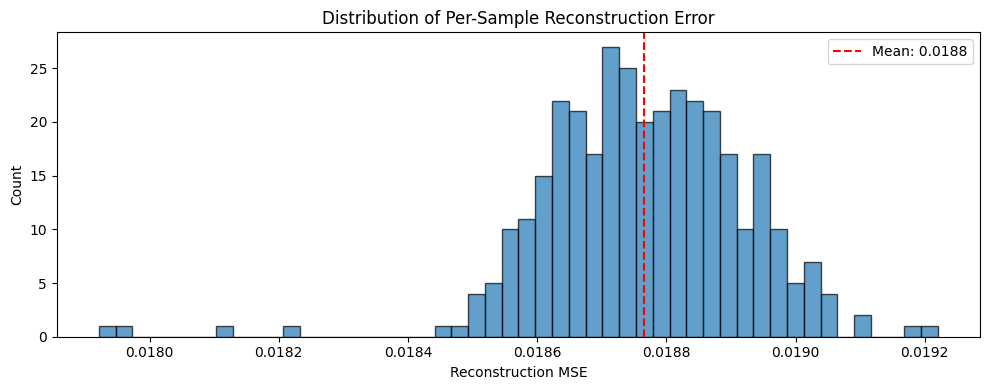

In [57]:
# Per-sample reconstruction error
per_sample_mse = ((X_hat - Xn) ** 2).mean(dim=1).cpu().numpy()

plt.figure(figsize=(10, 4))
plt.hist(per_sample_mse, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Reconstruction MSE')
plt.ylabel('Count')
plt.title('Distribution of Per-Sample Reconstruction Error')
plt.axvline(per_sample_mse.mean(), color='red', linestyle='--', label=f'Mean: {per_sample_mse.mean():.4f}')
plt.legend()
plt.tight_layout()
plt.show()


In [39]:
with torch.no_grad():
    x = Xn[:1024]       # normalized activations
    x_hat, z = sae(x)

    per_sample_mse = ((x_hat - x) ** 2).mean(dim=1)  # [batch]
    print("MSE stats:", per_sample_mse.min().item(), 
                        per_sample_mse.mean().item(), 
                        per_sample_mse.max().item())

    # how sparse are we actually?
    active = (z > 1e-4).float().sum(dim=1)  # number of active features
    print("Active features per sample (mean/min/max):",
          active.mean().item(), active.min().item(), active.max().item())

MSE stats: 0.013399112038314342 0.015245153568685055 0.019220585003495216
Active features per sample (mean/min/max): 64.0 64.0 64.0


In [ ]:
with torch.no_grad():
    x = Xn[:1024]       # normalized activations
    x_hat, z = sae(x)

    per_sample_mse = ((x_hat - x) ** 2).mean(dim=1)  # [batch]
    print("MSE stats:", per_sample_mse.min().item(), 
                        per_sample_mse.mean().item(), 
                        per_sample_mse.max().item())

    # how sparse are we actually?
    active = (z > 1e-4).float().sum(dim=1)  # number of active features
    print("Active features per sample (mean/min/max):",
          active.mean().item(), active.min().item(), active.max().item())

MSE stats: 0.013399112038314342 0.015245153568685055 0.019220585003495216
Active features per sample (mean/min/max): 64.0 64.0 64.0


In [40]:
print(f"d_hidden: {ckpt['d_hidden']}, num_samples: {len(metadata)}")
print(f"Ratio: {ckpt['d_hidden'] / len(metadata):.1f}x")

d_hidden: 8192, num_samples: 1000
Ratio: 8.2x


## 3. Sparsity Analysis


In [41]:
Z_cpu = Z.cpu().numpy()

# Per-sample sparsity (fraction of active features)
active_per_sample = (Z_cpu > 0).sum(axis=1)
sparsity = 1 - active_per_sample.mean() / Z_cpu.shape[1]

print(f"Mean active features per sample: {active_per_sample.mean():.1f} / {Z_cpu.shape[1]}")
print(f"Sparsity: {sparsity:.2%}")


Mean active features per sample: 64.0 / 8192
Sparsity: 99.22%


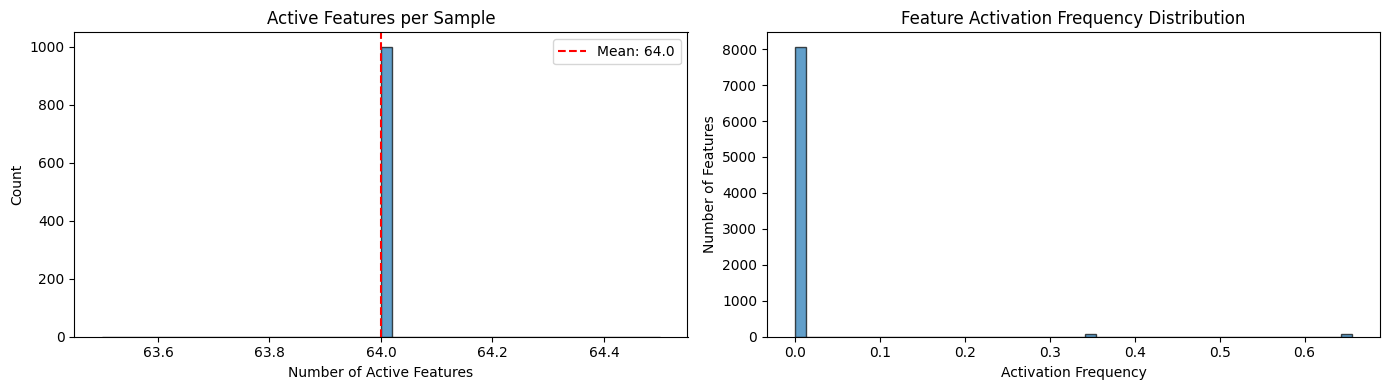

Dead features (never activate): 8061 (98.4%)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribution of active features per sample
axes[0].hist(active_per_sample, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Number of Active Features')
axes[0].set_ylabel('Count')
axes[0].set_title('Active Features per Sample')
axes[0].axvline(active_per_sample.mean(), color='red', linestyle='--', label=f'Mean: {active_per_sample.mean():.1f}')
axes[0].legend()

# Feature activation frequency
feature_freq = (Z_cpu > 0).mean(axis=0)
axes[1].hist(feature_freq, bins=50, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Activation Frequency')
axes[1].set_ylabel('Number of Features')
axes[1].set_title('Feature Activation Frequency Distribution')

plt.tight_layout()
plt.show()

# Dead features
dead_features = (feature_freq == 0).sum()
print(f"Dead features (never activate): {dead_features} ({dead_features/len(feature_freq):.1%})")


## 4. Top Activating Examples per Feature

For each SAE feature, find the clips that activate it most strongly.


In [43]:
def get_top_activating_clips(feature_idx, top_k=10):
    """Get the clips that most strongly activate a given feature."""
    activations = Z_cpu[:, feature_idx]
    top_indices = np.argsort(activations)[::-1][:top_k]
    
    results = []
    for idx in top_indices:
        clip_meta = metadata[idx]
        results.append({
            'clip_idx': idx,
            'activation': activations[idx],
            'metadata': clip_meta
        })
    return results


In [ ]:
# Find most frequently activated features (excluding dead ones)
active_feature_indices = np.where(feature_freq > 0)[0]
sorted_by_freq = active_feature_indices[np.argsort(feature_freq[active_feature_indices])[::-1]]

print(f"Top 10 most frequently activated features:")
for i, feat_idx in enumerate(sorted_by_freq[:10]):
    print(f"  Feature {feat_idx}: activates in {feature_freq[feat_idx]:.1%} of samples")


Top 10 most frequently activated features:
  Feature 247: activates in 65.6% of samples
  Feature 853: activates in 65.6% of samples
  Feature 573: activates in 65.6% of samples
  Feature 7445: activates in 65.6% of samples
  Feature 7366: activates in 65.6% of samples
  Feature 7234: activates in 65.6% of samples
  Feature 7231: activates in 65.6% of samples
  Feature 7070: activates in 65.6% of samples
  Feature 1551: activates in 65.6% of samples
  Feature 1547: activates in 65.6% of samples


In [48]:
from collections import Counter
# Check which samples activate feature 247
feat_247_active = Z_cpu[:, 247] > 0
print(f"Samples with feature 247 active: {feat_247_active.sum()}")

# Are the same 656 samples activating all these features?
top_feats = [247, 853, 573, 7445, 7366]
active_masks = [(Z_cpu[:, f] > 0) for f in top_feats]
all_same = all(np.array_equal(active_masks[0], m) for m in active_masks[1:])
print(f"Same 656 samples for all features? {all_same}")

# What's different about active vs inactive samples?
active_idx = np.where(feat_247_active)[0]
inactive_idx = np.where(~feat_247_active)[0]

print(f"\nActive samples keys:")
print(Counter([metadata[i].get('label_key') for i in active_idx[:50]]))
print(f"\nInactive samples keys:")
print(Counter([metadata[i].get('label_key') for i in inactive_idx[:50]]))

Samples with feature 247 active: 656
Same 656 samples for all features? True

Active samples keys:
Counter({'C_minor': 10, 'D#_major': 6, 'A#_major': 4, 'D#_minor': 4, 'D_minor': 3, 'G_minor': 3, 'E_minor': 3, 'B_major': 2, 'E_major': 2, 'C_major': 2, 'A_minor': 2, 'A#_minor': 1, 'B_minor': 1, 'G#_minor': 1, 'C#_minor': 1, 'F_major': 1, 'C#_major': 1, 'F_minor': 1, 'F#_minor': 1, 'G#_major': 1})

Inactive samples keys:
Counter({'F#_major': 6, 'D#_major': 6, 'C_minor': 5, 'G_minor': 4, 'A_minor': 4, 'G_major': 4, 'D#_minor': 3, 'C_major': 3, 'G#_minor': 2, 'D_minor': 2, 'A#_major': 2, 'G#_major': 2, 'E_major': 1, 'A#_minor': 1, 'E_minor': 1, 'A_major': 1, 'C#_major': 1, 'D_major': 1, 'B_major': 1})


In [49]:
# Check if some clips have identical activations
X_np = X.cpu().numpy()
print("Checking for duplicate activations...")

# Pairwise differences for first few clips
for i in range(340, 365):
    for j in range(i+1, min(i+5, 365)):
        diff = np.abs(X_np[i] - X_np[j]).max()
        if diff < 0.01:
            print(f"Clips {i} and {j} are nearly identical (max diff: {diff:.6f})")

# Check overall variance per clip
clip_vars = X_np.var(axis=1)
print(f"\nClip variance - min: {clip_vars.min():.4f}, max: {clip_vars.max():.4f}")
print(f"Low variance clips: {(clip_vars < clip_vars.mean()/10).sum()}")

Checking for duplicate activations...
Clips 344 and 345 are nearly identical (max diff: 0.000000)
Clips 344 and 346 are nearly identical (max diff: 0.000000)
Clips 344 and 347 are nearly identical (max diff: 0.000000)
Clips 344 and 348 are nearly identical (max diff: 0.000000)
Clips 345 and 346 are nearly identical (max diff: 0.000000)
Clips 345 and 347 are nearly identical (max diff: 0.000000)
Clips 345 and 348 are nearly identical (max diff: 0.000000)
Clips 345 and 349 are nearly identical (max diff: 0.000000)
Clips 346 and 347 are nearly identical (max diff: 0.000000)
Clips 346 and 348 are nearly identical (max diff: 0.000000)
Clips 346 and 349 are nearly identical (max diff: 0.000000)
Clips 346 and 350 are nearly identical (max diff: 0.000000)
Clips 347 and 348 are nearly identical (max diff: 0.000000)
Clips 347 and 349 are nearly identical (max diff: 0.000000)
Clips 347 and 350 are nearly identical (max diff: 0.000000)
Clips 347 and 351 are nearly identical (max diff: 0.000000)
Cl

In [45]:
# Analyze a specific feature
FEATURE_TO_ANALYZE = sorted_by_freq[0]  # Most frequent feature

print(f"\n=== Feature {FEATURE_TO_ANALYZE} ===")
print(f"Activation frequency: {feature_freq[FEATURE_TO_ANALYZE]:.1%}")
print(f"\nTop activating clips:")

top_clips = get_top_activating_clips(FEATURE_TO_ANALYZE, top_k=10)
for i, clip in enumerate(top_clips):
    print(f"  {i+1}. Clip {clip['clip_idx']}: activation={clip['activation']:.4f}")
    # Print relevant metadata fields if available
    meta = clip['metadata']
    if 'title' in meta:
        print(f"      Title: {meta['title']}")
    if 'genre' in meta:
        print(f"      Genre: {meta['genre']}")
    if 'key' in meta:
        print(f"      Key: {meta['key']}")



=== Feature 247 ===
Activation frequency: 65.6%

Top activating clips:
  1. Clip 351: activation=2.5246
  2. Clip 350: activation=2.5246
  3. Clip 349: activation=2.5246
  4. Clip 348: activation=2.5246
  5. Clip 347: activation=2.5246
  6. Clip 346: activation=2.5246
  7. Clip 345: activation=2.5246
  8. Clip 344: activation=2.5246
  9. Clip 359: activation=2.5246
  10. Clip 358: activation=2.5246


## 5. Decoder Direction Analysis

The decoder weights represent the "direction" each feature encodes in activation space.


In [ ]:
# Get decoder weights
W_dec = sae.decoder.weight.detach().cpu().numpy()  # [d_in, d_hidden]
print(f"Decoder weight shape: {W_dec.shape}")

# Norm of each feature direction
feature_norms = np.linalg.norm(W_dec, axis=0)

plt.figure(figsize=(10, 4))
plt.hist(feature_norms, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('L2 Norm of Decoder Direction')
plt.ylabel('Number of Features')
plt.title('Distribution of Feature Direction Magnitudes')
plt.tight_layout()
plt.show()


In [ ]:
# Cosine similarity between feature directions
W_dec_normalized = W_dec / (feature_norms + 1e-8)

if W_dec.shape[1] < 2000:
    cos_sim = W_dec_normalized.T @ W_dec_normalized
    
    # Distribution of pairwise cosine similarities (excluding diagonal)
    triu_indices = np.triu_indices(cos_sim.shape[0], k=1)
    pairwise_sims = cos_sim[triu_indices]
    
    plt.figure(figsize=(10, 4))
    plt.hist(pairwise_sims, bins=100, edgecolor='black', alpha=0.7)
    plt.xlabel('Cosine Similarity')
    plt.ylabel('Count')
    plt.title('Pairwise Cosine Similarity Between Feature Directions')
    plt.axvline(0, color='red', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
    
    print(f"Mean pairwise cosine similarity: {pairwise_sims.mean():.4f}")
    print(f"Std pairwise cosine similarity: {pairwise_sims.std():.4f}")
else:
    print("Too many features for full correlation visualization - sampling...")


## 6. Temporal Patterns

Analyze how features activate across time within clips.


In [ ]:
def get_temporal_activations(clip_idx, feature_idx):
    """Get SAE feature activations across time for a single clip."""
    clip_acts = acts[clip_idx]  # [T, D]
    clip_acts_tensor = torch.from_numpy(clip_acts.astype(np.float32)).to(DEVICE)
    clip_acts_norm = (clip_acts_tensor - mu) / sigma
    
    with torch.no_grad():
        _, z_temporal = sae(clip_acts_norm)  # [T, d_hidden]
    
    return z_temporal[:, feature_idx].cpu().numpy()


In [ ]:
# Visualize temporal activation for top feature on top clips
FEATURE_IDX = sorted_by_freq[0]
top_clips = get_top_activating_clips(FEATURE_IDX, top_k=3)

fig, axes = plt.subplots(len(top_clips), 1, figsize=(12, 3*len(top_clips)))
if len(top_clips) == 1:
    axes = [axes]

for i, clip_info in enumerate(top_clips):
    temporal_act = get_temporal_activations(clip_info['clip_idx'], FEATURE_IDX)
    axes[i].plot(temporal_act)
    axes[i].set_xlabel('Time Step')
    axes[i].set_ylabel('Activation')
    axes[i].set_title(f"Feature {FEATURE_IDX} - Clip {clip_info['clip_idx']} (mean act: {clip_info['activation']:.3f})")
    axes[i].axhline(0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


## 7. Summary Statistics for Paper


In [ ]:
print("=" * 50)
print("SAE SUMMARY STATISTICS")
print("=" * 50)
print(f"\nModel Architecture:")
print(f"  Input dimension: {ckpt['d_in']}")
print(f"  Hidden dimension: {ckpt['d_hidden']}")
print(f"  Expansion factor: {ckpt['d_hidden'] / ckpt['d_in']:.1f}x")
print(f"  L1 lambda: {ckpt['l1_lambda']}")

print(f"\nDataset:")
print(f"  Number of clips: {len(metadata)}")
print(f"  Layer analyzed: {LAYER_IDX}")

print(f"\nReconstruction Quality:")
print(f"  MSE: {mse:.6f}")
print(f"  Variance explained: {var_explained:.2%}")

print(f"\nSparsity:")
print(f"  Mean active features per sample: {active_per_sample.mean():.1f}")
print(f"  Sparsity: {sparsity:.2%}")
print(f"  Dead features: {dead_features} ({dead_features/ckpt['d_hidden']:.1%})")
print(f"  Active features (>1% freq): {(feature_freq > 0.01).sum()}")
print("=" * 50)
